In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , mean_absolute_error,r2_score

In [109]:
#Loading Data
df = pd.read_csv('data/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [110]:
# Confirm no missing values after dropping columns
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [111]:
#Dataset structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [112]:
# Unique values per column
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [113]:
# Check class distribution before dropping columns

df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [114]:
# Drop useless and Leakage columns
df = df.drop(['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'],axis=1)

In [115]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>],
       [<Axes: title={'center': 'Tool wear [min]'}>,
        <Axes: title={'center': 'Machine failure'}>]], dtype=object)

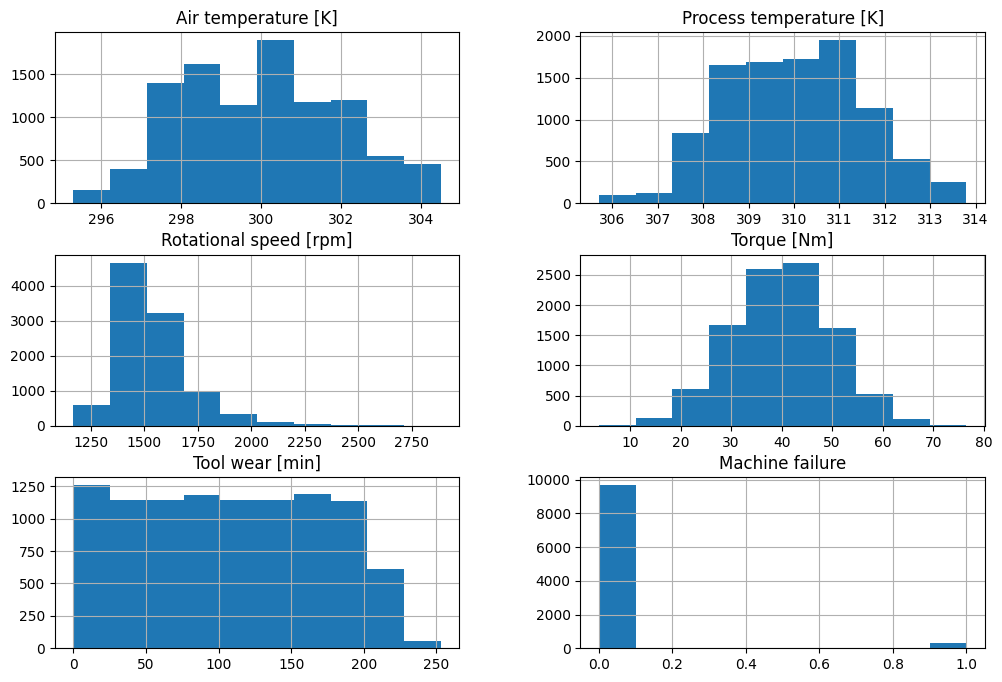

In [116]:
# Distribution of all numeric features
df.hist(figsize=(12,8))

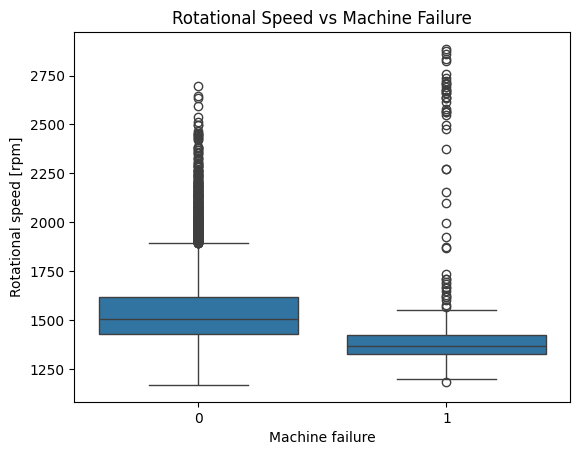

In [117]:
#rpm is right-skewed

sns.boxplot(x='Machine failure',y='Rotational speed [rpm]' , data=df)
plt.title('Rotational Speed vs Machine Failure')
plt.show() 

In [118]:
# Median torque by failure class
df.groupby('Machine failure')['Torque [Nm]'].median()

Machine failure
0    39.9
1    53.7
Name: Torque [Nm], dtype: float64

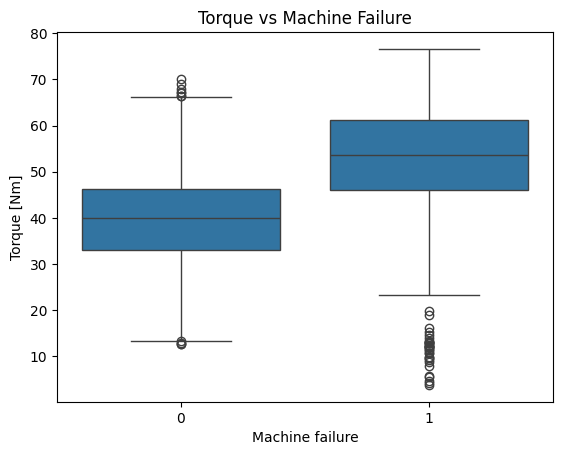

In [119]:
sns.boxplot(x='Machine failure' , y='Torque [Nm]',data=df)
plt.title('Torque vs Machine Failure')
plt.show()

In [120]:
# Median tool wear by failure class
df.groupby('Machine failure')['Tool wear [min]'].median()

Machine failure
0    107.0
1    165.0
Name: Tool wear [min], dtype: float64

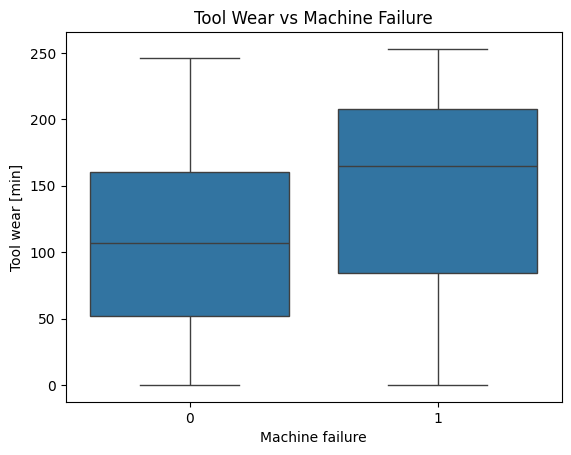

In [121]:
sns.boxplot(x='Machine failure',y='Tool wear [min]',data=df)
plt.title('Tool Wear vs Machine Failure')  
plt.show()   

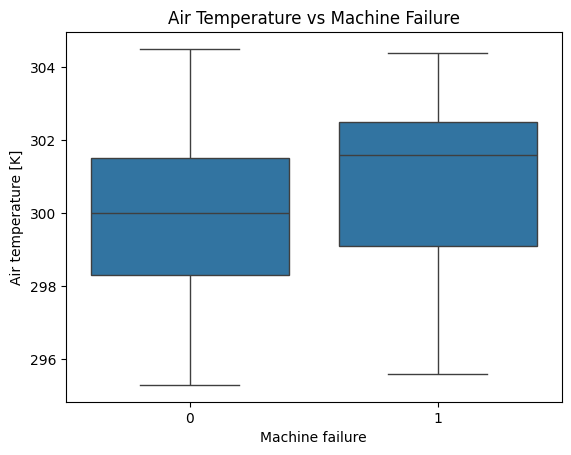

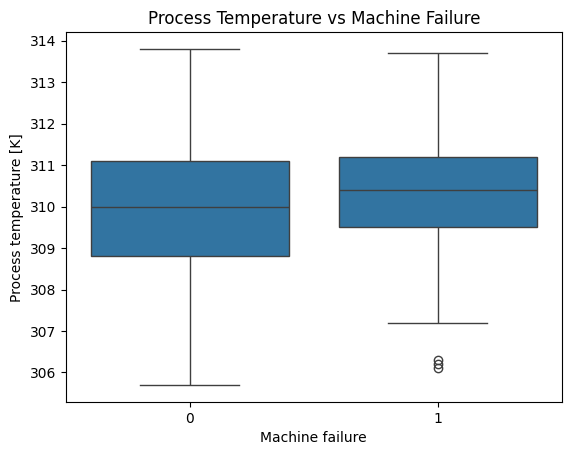

In [122]:
sns.boxplot(x='Machine failure', y='Air temperature [K]', data=df)
plt.title('Air Temperature vs Machine Failure')
plt.show()

sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df)
plt.title('Process Temperature vs Machine Failure')
plt.show()

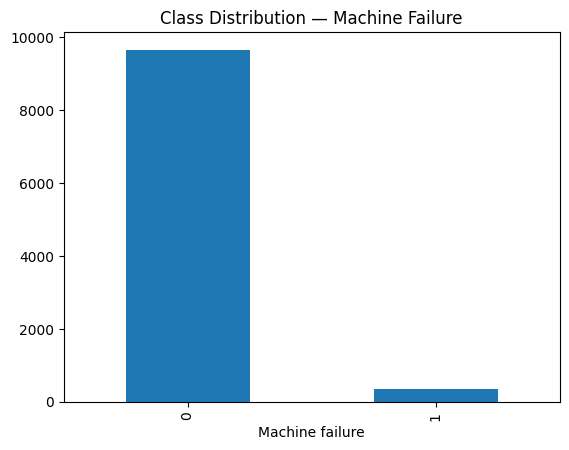

In [123]:
df['Machine failure'].value_counts().plot(kind='bar')
plt.title('Class Distribution — Machine Failure')
plt.show()

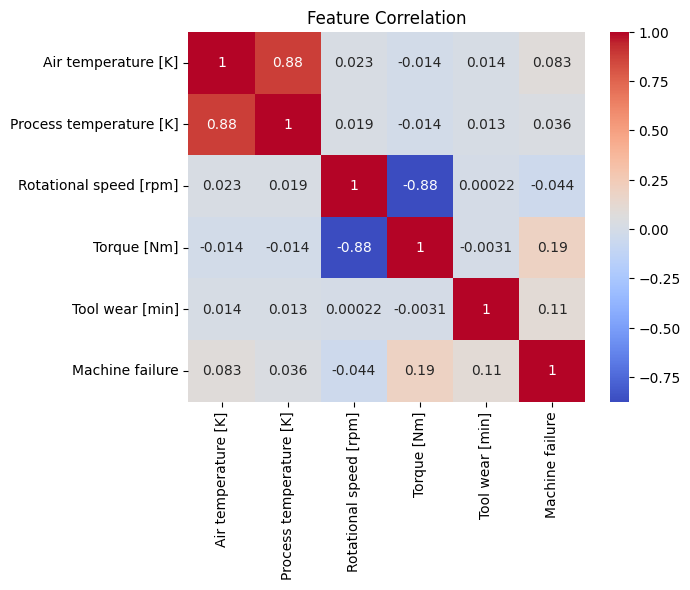

In [124]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [125]:
# Median temperatures by failure class
df.groupby('Machine failure')[['Air temperature [K]', 'Process temperature [K]']].median()

,Air temperature [K],Process temperature [K]
Machine failure,,
0,300.0,310.0
1,301.6,310.4


In [126]:
# Encode categorical Type column and define features/target
X= df.drop('Machine failure',axis=1)
y= df['Machine failure']
X= pd.get_dummies(X,columns=['Type'])

In [127]:
# Split data — stratify preserves class imbalance ratio
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2 , stratify=y, random_state=42)

In [128]:
# Verify class ratio is preserved in both sets
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64

In [129]:
#Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [130]:
# Baseline model with class_weight to handle imbalance
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred))

Logistic Regression Accuracy: 0.825


In [131]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [132]:
sum(y_pred)


np.int64(394)

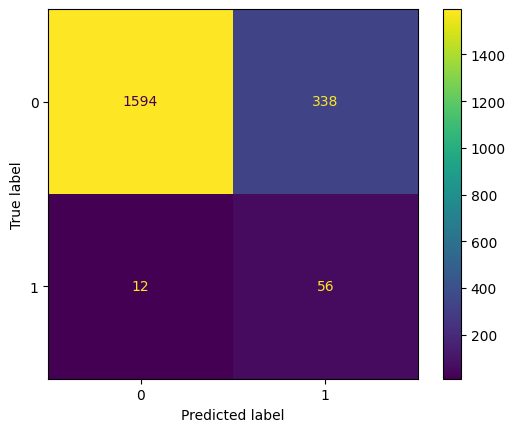

In [133]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [134]:
# More powerful ensemble model
rf_model = RandomForestClassifier()
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

Random Forest Accuracy: 0.9815
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [135]:
#“Random Forest achieved higher accuracy, but struggled with recall on the minority class. Logistic Regression had better recall but poor precision. I would improve the model using class balancing techniques.” 


In [136]:
# Oversample minority class to improve recall
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)  # ← original data

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_sm, y_train_sm)
thresholds = [0.3, 0.4, 0.5, 0.6]
for t in thresholds:
    y_prob = rf_model.predict_proba(X_test)[:, 1]
    y_pred_t = (y_prob >= t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred_t))
    print("-" * 50)

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1932
           1       0.34      0.85      0.48        68

    accuracy                           0.94      2000
   macro avg       0.67      0.90      0.73      2000
weighted avg       0.97      0.94      0.95      2000

--------------------------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.40      0.81      0.53        68

    accuracy                           0.95      2000
   macro avg       0.69      0.88      0.75      2000
weighted avg       0.97      0.95      0.96      2000

--------------------------------------------------
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.46      0.76      0.58        68

    accuracy                       

In [137]:
# Best model — handles imbalance via scale_pos_weight
from xgboost import XGBClassifier

xgb_model = XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                           random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.76      0.74        68

    accuracy                           0.98      2000
   macro avg       0.85      0.88      0.86      2000
weighted avg       0.98      0.98      0.98      2000

